In [1]:
#install required lib

!pip install torch torchvision torchaudio -q
!pip install torch-geometric -q
!pip install networkx -q
!pip install scikit-learn -q


In [2]:
#import lib

import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

from sklearn.neighbors import kneighbors_graph

import networkx as nx
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")


In [3]:
#load processed data

df = pd.read_csv("../data/processed.csv")

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)

print("Shape:", df.shape)

print(
    "Fraud Rate:",
    round((df['fraudfound_p'] == 1).mean() * 100, 2),
    "%"
)

print("=" * 70)

df.head()


DATASET LOADED
Shape: (15420, 52)
Fraud Rate: 5.99 %


,month,weekofmonth,dayofweek,make,accidentarea,dayofweekclaimed,monthclaimed,weekofmonthclaimed,sex,maritalstatus,...,speed_volatility,harsh_braking_risk,harsh_acceleration_risk,harsh_cornering_risk,harsh_driving_index,high_night_driving,high_urban_driving,fast_claim,high_claim_history,claim_driving_risk
0,2,1.717545,6,6,1,6,5,-1.345408,0,2,...,0.725376,-0.301255,-0.524215,-0.134501,-0.340056,-0.990062,1.139325,-0.008053,-0.972492,-0.008053
1,4,0.164199,6,6,1,2,5,1.037295,1,2,...,-0.317649,-0.301255,1.907613,-0.134501,1.661724,-0.990062,1.139325,-0.008053,-0.972492,-0.008053
2,10,1.717545,0,6,1,5,10,-0.551174,1,1,...,1.399306,-0.301255,-0.524215,-0.134501,-0.006426,1.010037,1.139325,-0.008053,-0.972492,-0.008053
3,6,-0.612473,2,17,0,1,6,-1.345408,1,1,...,-0.821335,-0.301255,1.907613,-0.134501,0.994464,-0.990062,1.139325,-0.008053,-0.972492,-0.008053
4,4,1.717545,1,6,1,6,4,-0.551174,0,2,...,0.170197,-0.301255,-0.524215,-0.134501,-1.340946,-0.990062,1.139325,-0.008053,-0.972492,-0.008053


In [4]:
#speed boost if laptop slow

df = df.sample(5000, random_state=42).reset_index(drop=True)

In [5]:
#set target solumn

target_col = "fraudfound_p"

In [6]:
#feature selction

feature_cols = [

    # ========================================================
    # TELEMATICS FEATURES
    # ========================================================

    'avg_speed_kmph',
    'max_speed_kmph',
    'hard_brakes_per_trip',
    'rapid_acceleration_events',
    'trip_duration_minutes',
    'distance_km',
    'night_driving_ratio',
    'urban_driving_ratio',
    'harsh_cornering_events',
    'idle_time_minutes',

    # ========================================================
    # ENGINEERED DRIVING FEATURES
    # ========================================================

    'speeding_risk',
    'speed_volatility',
    'harsh_braking_risk',
    'harsh_acceleration_risk',
    'harsh_cornering_risk',
    'harsh_driving_index',
    'high_night_driving',
    'high_urban_driving',

    # ========================================================
    # CLAIM FEATURES
    # ========================================================

    'fast_claim',
    'high_claim_history',
    'claim_driving_risk',

    # ========================================================
    # INSURANCE FEATURES
    # ========================================================

    'deductible',
    'driverrating',
    'policytype',
    'vehiclecategory',
    'vehicleprice',

    # ========================================================
    # CUSTOMER FEATURES
    # ========================================================

    'age',
    'sex',
    'maritalstatus',

    # ========================================================
    # VEHICLE FEATURES
    # ========================================================

    'ageofvehicle',

    # ========================================================
    # ENVIRONMENT FEATURES
    # ========================================================

    'accidentarea'
]

print("Total Features Used:", len(feature_cols))


Total Features Used: 31


In [7]:
#feature matrix

X = df[feature_cols].values

X = torch.tensor(
    X,
    dtype=torch.float
)

y = torch.tensor(
    df[target_col].values,
    dtype=torch.long
)

print("Feature Tensor Shape:", X.shape)

print("Target Shape:", y.shape)



Feature Tensor Shape: torch.Size([5000, 31])
Target Shape: torch.Size([5000])


In [8]:
#graph construction using KNN

print("=" * 70)
print("CREATING FAST KNN FRAUD GRAPH")
print("=" * 70)

# Each node connects to 10 nearest similar claims

knn_graph = kneighbors_graph(

    df[feature_cols],

    n_neighbors=10,

    mode='connectivity',

    include_self=False,

    metric='cosine'
)

# Extract graph connections

row_indices, col_indices = knn_graph.nonzero()

# Create edge index

edge_index = torch.tensor(

    [row_indices, col_indices],

    dtype=torch.long
)

print("Edge Index Shape:", edge_index.shape)

print("Total Graph Edges:", edge_index.shape[1])



CREATING FAST KNN FRAUD GRAPH
Edge Index Shape: torch.Size([2, 50000])
Total Graph Edges: 50000


In [9]:
#create PyTorch geometric data object

data = Data(

    x=X,

    edge_index=edge_index,

    y=y
)

print(data)

Data(x=[5000, 31], edge_index=[2, 50000], y=[5000])


VISUALIZING GRAPH SAMPLE


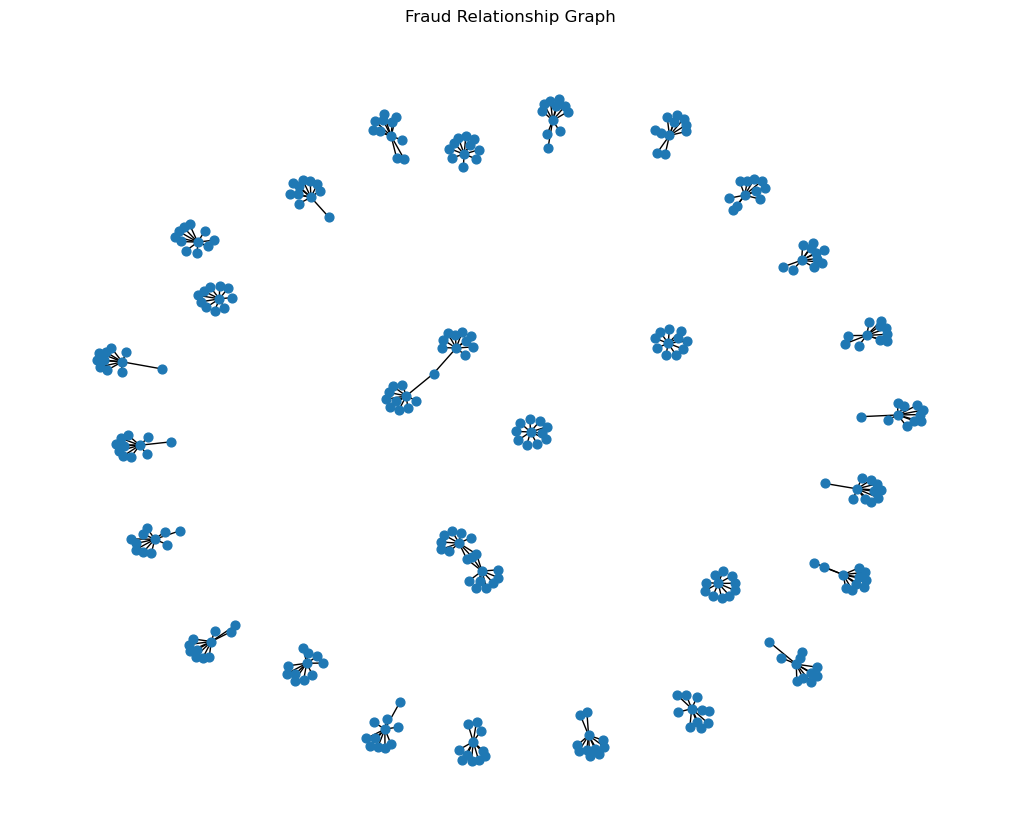

In [10]:
#visualize small graph

print("=" * 70)
print("VISUALIZING GRAPH SAMPLE")
print("=" * 70)

G = nx.Graph()

# Convert edge index to numpy

edge_array = edge_index.numpy()

# Take only first 300 edges for visualization

src_nodes = edge_array[0][:300]

dst_nodes = edge_array[1][:300]

# Create edge list

edge_list = list(zip(src_nodes, dst_nodes))

# Add edges

G.add_edges_from(edge_list)

plt.figure(figsize=(10, 8))

nx.draw(

    G,

    node_size=40,

    with_labels=False
)

plt.title("Fraud Relationship Graph")

plt.show()

In [11]:
#define GNN

class FraudGCN(torch.nn.Module):

    def __init__(self, input_dim):

        super(FraudGCN, self).__init__()

        # ====================================================
        # GCN LAYERS
        # ====================================================

        self.conv1 = GCNConv(input_dim, 64)

        self.conv2 = GCNConv(64, 32)

        self.conv3 = GCNConv(32, 2)

        # ====================================================
        # DROPOUT
        # ====================================================

        self.dropout = torch.nn.Dropout(0.30)

    def forward(self, data):

        x, edge_index = data.x, data.edge_index

        # ====================================================
        # FIRST GCN LAYER
        # ====================================================

        x = self.conv1(x, edge_index)

        x = F.relu(x)

        x = self.dropout(x)

        # ====================================================
        # SECOND GCN LAYER
        # ====================================================

        x = self.conv2(x, edge_index)

        x = F.relu(x)

        # Save embeddings

        embeddings = x

        # ====================================================
        # OUTPUT LAYER
        # ====================================================

        x = self.conv3(x, edge_index)

        return F.log_softmax(x, dim=1), embeddings


In [12]:
#initialize model

model = FraudGCN(

    input_dim=X.shape[1]
)

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001,

    weight_decay=5e-4
)

#handle imbalalnced fraud data

class_weights = torch.tensor([1.0, 15.0])

criterion = torch.nn.NLLLoss(

    weight=class_weights
)

print(model)

FraudGCN(
  (conv1): GCNConv(31, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(32, 2)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [13]:
#train-test split

indices = np.arange(len(df))

train_idx, test_idx = train_test_split(

    indices,

    test_size=0.20,

    stratify=df[target_col],

    random_state=42
)

train_idx = torch.tensor(train_idx)

test_idx = torch.tensor(test_idx)

print("Training Samples:", len(train_idx))

print("Testing Samples:", len(test_idx))


Training Samples: 4000
Testing Samples: 1000


In [14]:
#train GNN model

print("=" * 70)
print("TRAINING GNN MODEL")
print("=" * 70)

model.train()

for epoch in range(120):

    optimizer.zero_grad()

    out, embeddings = model(data)

    loss = criterion(

        out[train_idx],

        y[train_idx]
    )

    loss.backward()

    optimizer.step()

    # ========================================================
    # PRINT EVERY 10 EPOCHS
    # ========================================================

    if epoch % 10 == 0:

        pred = out[test_idx].argmax(dim=1)

        acc = (

            (pred == y[test_idx])

            .sum()

            .item()

            /

            len(test_idx)
        )

        print(

            f"Epoch {epoch:03d}"

            f" | Loss: {loss.item():.4f}"

            f" | Accuracy: {acc:.4f}"
        )


TRAINING GNN MODEL
Epoch 000 | Loss: 0.7021 | Accuracy: 0.4300
Epoch 010 | Loss: 0.6683 | Accuracy: 0.5520
Epoch 020 | Loss: 0.6364 | Accuracy: 0.6370
Epoch 030 | Loss: 0.6152 | Accuracy: 0.5640
Epoch 040 | Loss: 0.6230 | Accuracy: 0.6350
Epoch 050 | Loss: 0.6006 | Accuracy: 0.6150
Epoch 060 | Loss: 0.5943 | Accuracy: 0.6160
Epoch 070 | Loss: 0.5839 | Accuracy: 0.6020
Epoch 080 | Loss: 0.5746 | Accuracy: 0.6410
Epoch 090 | Loss: 0.5659 | Accuracy: 0.6250
Epoch 100 | Loss: 0.5603 | Accuracy: 0.6230
Epoch 110 | Loss: 0.5525 | Accuracy: 0.6140


In [15]:
#final evaluation

print("=" * 70)
print("FINAL MODEL EVALUATION")
print("=" * 70)

model.eval()

out, graph_embeddings = model(data)

predictions = out[test_idx].argmax(dim=1)

probabilities = torch.exp(
    out[test_idx]
)[:, 1]

print(

    classification_report(

        y[test_idx].cpu(),

        predictions.cpu(),

        zero_division=0
    )
)

print("=" * 70)

print("Accuracy Score:")

print(

    accuracy_score(

        y[test_idx].cpu(),

        predictions.cpu()
    )
)

print("=" * 70)

print("ROC AUC Score:")

print(

    roc_auc_score(

        y[test_idx].cpu(),

        probabilities.detach().cpu()
    )
)

print("=" * 70)

print("Confusion Matrix:")

print(

    confusion_matrix(

        y[test_idx].cpu(),

        predictions.cpu()
    )
)



FINAL MODEL EVALUATION
              precision    recall  f1-score   support

           0       0.96      0.61      0.74       940
           1       0.09      0.60      0.15        60

    accuracy                           0.60      1000
   macro avg       0.52      0.60      0.45      1000
weighted avg       0.91      0.60      0.71      1000

Accuracy Score:
0.605
ROC AUC Score:
0.6510106382978723
Confusion Matrix:
[[569 371]
 [ 24  36]]


In [16]:
#generate fraud risk scores

print("=" * 70)
print("GENERATING FRAUD RISK SCORES")
print("=" * 70)

full_probabilities = torch.exp(out)[:, 1]

df['fraud_risk_score'] = (

    full_probabilities

    .detach()

    .cpu()

    .numpy()
)

df[['fraud_risk_score']].head()


GENERATING FRAUD RISK SCORES


,fraud_risk_score
0,0.585796
1,0.052806
2,0.363385
3,0.745747
4,0.475340


In [17]:
#extract graph embeddings

print("=" * 70)
print("EXTRACTING GRAPH EMBEDDINGS")
print("=" * 70)

graph_embeddings = (

    graph_embeddings

    .detach()

    .cpu()

    .numpy()
)

graph_df = pd.DataFrame(
    graph_embeddings
)

print("Embedding Shape:", graph_df.shape)

graph_df.head()

EXTRACTING GRAPH EMBEDDINGS
Embedding Shape: (5000, 32)


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,0.000000,0.0,0.830666,0.284289,0.000000,0.304311,0.161791,0.576618,0.0,0.000000,...,0.000000,0.046636,0.0,0.296353,0.614501,0.000000,0.000000,0.037154,0.508206,0.312606
1,0.397432,0.0,0.569443,0.000000,0.000000,0.000000,0.000000,0.512283,0.0,0.000000,...,1.347110,0.000000,0.0,0.940545,0.000000,0.654356,0.000000,0.143896,0.854431,0.905477
2,0.000000,0.0,0.833530,0.000000,0.033006,0.018218,0.000000,0.000000,0.0,0.282266,...,0.356751,0.000000,0.0,0.970732,0.246719,0.141026,0.339241,0.000000,1.001544,0.425399
3,0.203420,0.0,0.728818,0.000000,0.916022,0.000000,1.413713,0.268925,0.0,0.000000,...,0.913892,0.928685,0.0,1.027811,0.000000,0.000000,1.960191,0.071529,0.555070,1.048706
4,0.000000,0.0,0.680170,0.000000,0.000000,0.236279,0.000000,0.527096,0.0,0.000000,...,0.000000,0.039428,0.0,0.429163,0.657096,0.000000,0.000000,0.026709,0.491544,0.466036


In [18]:
#save graph embeddings

graph_df.to_csv(

    "../data/graph_embeddings.csv",

    index=False
)

print("✓ Graph embeddings saved")


✓ Graph embeddings saved


In [19]:
#save GNN output
df.to_csv(

    "../data/gnn_output.csv",

    index=False
)

print("✓ GNN output saved")

✓ GNN output saved


In [20]:
#final summary

print("\n" + "=" * 80)

print("✓ GRAPH NEURAL NETWORK MODULE COMPLETE")

print("=" * 80)

print(f"Dataset Shape: {df.shape}")

print(f"Total Graph Edges: {edge_index.shape[1]}")

print(f"Fraud Rate: {(df['fraudfound_p'] == 1).mean() * 100:.2f}%")

print(f"Embeddings Generated: {graph_df.shape[1]}")

print("\nSaved Files:")

print("1. ../data/graph_embeddings.csv")

print("2. ../data/gnn_output.csv")

print("=" * 80)


✓ GRAPH NEURAL NETWORK MODULE COMPLETE
Dataset Shape: (5000, 53)
Total Graph Edges: 50000
Fraud Rate: 6.02%
Embeddings Generated: 32

Saved Files:
1. ../data/graph_embeddings.csv
2. ../data/gnn_output.csv
